# Momentum and KE budgets in NeverWorld2

In [3]:
from netCDF4 import Dataset
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import xarray as xr
from xgcm import Grid
from dask.diagnostics import ProgressBar
import matplotlib.pylab as pylab
import palettable

## Open NW2 data

In [4]:
deg_list = [4,8,16]
end_time_list = [32500,32500,32500]
exp_list = ['1/4 deg','1/8 deg','1/16 deg']

deg_list = [16]
end_time_list = [32500]
exp_list = ['1/16 deg']

In [5]:
av_list = []
av_eta_list = []
av_psi_list = []
st_list = []
for i in range(len(deg_list)):
    deg = deg_list[i]

    if deg == 4:
        run = 20
        chunks = {'time': 50}  
    elif deg == 8:
        run = 26 
        chunks = {'time': 20}    
    elif deg == 16:
        run = 28 
        chunks = {'time': 5}
    elif deg == 32:
        run = 34 
        chunks = {'time': 1}      
    stdummy = xr.open_dataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/static.nc' % (run), decode_times=False)
    st_list.append(stdummy)
    
    if deg == 32:
        dummy = xr.open_mfdataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/averages_*.nc' % (run),
                       combine="by_coords", decode_times=False, compat='override', coords='minimal',
                       chunks=chunks)        
    else:
        end_time = end_time_list[i]
        ffile = '/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/averages_000%i.nc' % (run,end_time-500+2)
        dummy = xr.open_dataset(ffile, decode_times=False,chunks=chunks)
        
        eta_file = '/glade/work/noraloose/run%i/eta_averages_000%i.nc' % (run,end_time-500+2)
        eta_dummy = xr.open_dataset(eta_file, decode_times=False,chunks=chunks)
        
        psi_file = '/glade/work/noraloose/run%i/psi_averages_000%i.nc' % (run,end_time-500+2)
        psi_dummy = xr.open_dataset(psi_file, decode_times=False,chunks=chunks)

    av_list.append(dummy)
    av_eta_list.append(eta_dummy)
    av_psi_list.append(psi_dummy)

In [6]:
av = av_list[0]
av_eta = av_eta_list[0]
av_psi = av_psi_list[0]
st = st_list[0]
## only consider last 100 time steps
#av = av.isel(time=slice(-101,-1))

In [7]:
nr_days = 500
sn = xr.open_dataset('/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/snapshots_000%i.nc' % (run, end_time-nr_days+5),
                         decode_times=False,chunks=chunks)
import os.path
from os import path
snfile = '/glade/p/univ/unyu0004/neerajab/NeverWorld2/run%i/snapshots_000%i.nc' % (run, end_time-2*nr_days+5)
if path.exists(snfile):
    sn_previous = xr.open_dataset(snfile,decode_times=False,chunks=chunks)
    doStep0 = 1
else: 
    doStep0 = 0

if np.all(av.average_DT == av.average_DT[0]):
    deltat = av.average_DT[0] * 24 * 60 * 60
else: 
    raise AssertionError('averaging intervals vary')
    
if np.array_equal(av.time_bnds[:,1],sn.time) :
    dhdt = sn['h'] - sn['h'].shift(time=1)
    dhdt = dhdt/deltat
    dhdt['time'] = av['h'].time
else: 
    raise AssertionError('av and sn datasets not compatitble')

if doStep0 and sn_previous.time[-1].values == av.time_bnds[0,0].values:
    data = sn['h'].isel(time=0) - sn_previous['h'].isel(time=-1)
    data = (data/deltat)
    dhdt = xr.where(av.time==av.time[0],data.copy(),dhdt)  
else:
    doStep0 = 0
    
av['dhdt'] = dhdt.copy()
av['dhdt'].attrs = {'units' : 'm/s', 'long_name': 'Layer thickness tendency'}

In [8]:
Nx = np.size(st.xh)
Ny = np.size(st.yh)

coords = {'X': {'center': 'xh', 'outer': 'xq'},
            'Y': {'center': 'yh', 'outer': 'yq'},
            'Z': {'center': 'zl', 'outer': 'zi'} }
grid = Grid(st, coords=coords, periodic=['X'])

st['dxT'] = grid.interp(st.dxCu,'X')
st['dyT'] = grid.interp(st.dyCv,'Y')
st['dxBu'] = grid.interp(st.dxCv,'X')
st['dyBu'] = grid.interp(st.dyCu,'Y',boundary='fill')

metrics = {('X',):['dxCu','dxCv','dxT','dxBu'],
           ('Y',):['dyCu','dyCv','dyT','dyBu']
          }
grid = Grid(st, coords=coords, periodic=['X'], metrics=metrics)

In [9]:
sn

<xarray.Dataset>
Dimensions:  (time: 100, xh: 960, xq: 961, yh: 2240, yq: 2241, zl: 15)
Coordinates:
  * xq       (xq) float64 0.0 0.0625 0.125 0.1875 ... 59.81 59.88 59.94 60.0
  * yh       (yh) float64 -69.97 -69.91 -69.84 -69.78 ... 69.84 69.91 69.97
  * zl       (zl) float64 1.023e+03 1.023e+03 1.023e+03 ... 1.028e+03 1.028e+03
  * time     (time) float64 3.200e+04 3.201e+04 3.202e+04 ... 3.25e+04 3.25e+04
  * xh       (xh) float64 0.03125 0.09375 0.1562 0.2188 ... 59.84 59.91 59.97
  * yq       (yq) float64 -70.0 -69.94 -69.88 -69.81 ... 69.81 69.88 69.94 70.0
Data variables:
    u        (time, zl, yh, xq) float32 dask.array<chunksize=(5, 15, 2240, 961), meta=np.ndarray>
    v        (time, zl, yq, xh) float32 dask.array<chunksize=(5, 15, 2241, 960), meta=np.ndarray>
    h        (time, zl, yh, xh) float32 dask.array<chunksize=(5, 15, 2240, 960), meta=np.ndarray>
    KE       (time, zl, yh, xh) float32 dask.array<chunksize=(5, 15, 2240, 960), meta=np.ndarray>
Attributes:
    filename:          snapshots_00032005.nc
    title:             NeverWorld2
    associated_files:  area_t: static.nc
    grid_type:         regular
    grid_tile:         N/A

### Compare $\nabla\cdot(uh)$ and $\texttt{dhdt}$

In [36]:
uflux = av['uh']
uflux = grid.diff(uflux.fillna(value=0),'X')
vflux = av['vh']
vflux = grid.diff(vflux.fillna(value=0),'Y')
data1 = (uflux + vflux)/st.area_t

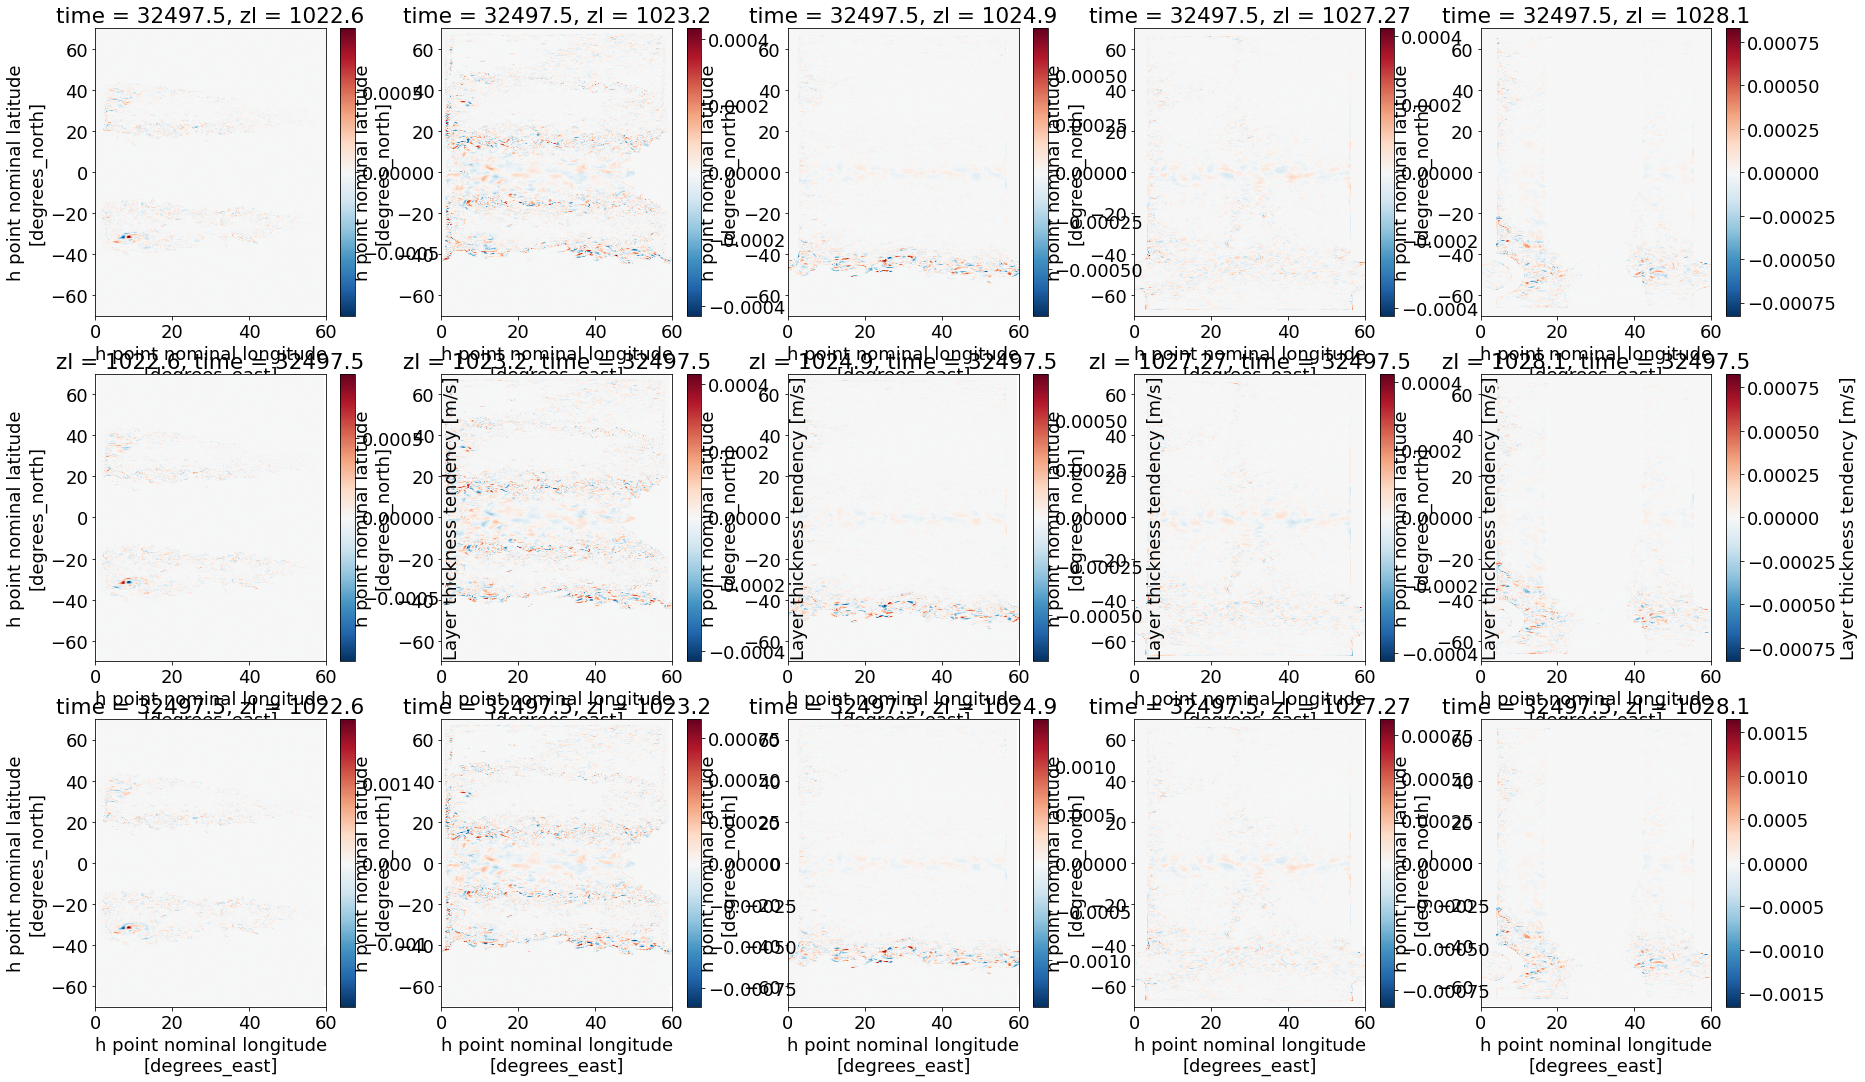

In [37]:
time = -1
fig,axs = plt.subplots(3,5,figsize=(30,18))

data1.isel(time=time,zl=0).plot(ax=axs[0,0])
av['dhdt'].isel(time=time,zl=0).plot(ax=axs[1,0])
(data1-av['dhdt']).isel(time=time,zl=0).plot(ax=axs[2,0])

data1.isel(time=time,zl=2).plot(ax=axs[0,1])
av['dhdt'].isel(time=time,zl=2).plot(ax=axs[1,1])
(data1-av['dhdt']).isel(time=time,zl=2).plot(ax=axs[2,1])

data1.isel(time=time,zl=5).plot(ax=axs[0,2])
av['dhdt'].isel(time=time,zl=5).plot(ax=axs[1,2])
(data1-av['dhdt']).isel(time=time,zl=5).plot(ax=axs[2,2])

data1.isel(time=time,zl=10).plot(ax=axs[0,3])
av['dhdt'].isel(time=time,zl=10).plot(ax=axs[1,3])
(data1-av['dhdt']).isel(time=time,zl=10).plot(ax=axs[2,3])

data1.isel(time=time,zl=14).plot(ax=axs[0,4])
av['dhdt'].isel(time=time,zl=14).plot(ax=axs[1,4])
(data1-av['dhdt']).isel(time=time,zl=14).plot(ax=axs[2,4])

In [6]:
ds = xr.Dataset() # new xarray dataset 

for fld in av.dims:
    ds[fld] = av[fld]

## Velocity budget

The momentum equation for layer $k$ is given by

\begin{align}
    \frac{\partial \mathbf{u}_k}{\partial t} + \left(\frac{{f} + {\zeta}_k}{h_k} \right) \hat{\mathbf{k}} \times \left( \mathbf{u}_k h_k \right) + \nabla K_k = - \sum_{i=1}^{k} g_{i-1/2}^\prime \nabla \eta_{i-1/2} + F_{hor} + F_{vert}
    \; 
    \label{eqn:u} \;,
\end{align}

where $\mathbf{u}_k$ is the horizontal velocity of layer $k$, $h_k$ is the layer thickness, and $\eta_k$ is the height of the upper surface of the layer relative to the reference height. 
$\zeta_k\hat{\mathbf{k}} \equiv \nabla \times \mathbf{u}_k$ and $K_k = \left(\mathbf{u}_k \cdot \mathbf{u}_k \right)/2$. $F_{hor}$ and $F_{vert}$ are the horizontal and vertical friction terms. In the model, the zonal and meridional components of the second term, $- \left(({f} + {\zeta}_k)/ h_k \right) \hat{\mathbf{k}} \times \left( \mathbf{u}_k h_k \right) - \nabla K_k$, are diagnosed as CAu and CAv. The first term on the RHS, the pressure force accelaration has two components: baroclinic (diagnosed as PFu and PFv) and barotropic (diagnosed as u_BT_accel and v_BT_accel). 

Note that the equation for KE is obtained by multipying the above equation by $\mathbf{u}_k h_k$, and so the terms in the KE budget have a one-to-one correspondence with the terms in the momentum budget. 

Here we evaluate the meridional and zonal components of the momentum equation separately, for a single averaging period (of 5 days) and a single layer.

### Compute Coriolis

In [ ]:
for i in range(len(deg_list)):
    av = av_list[i]

    data = av['CAu'] - av['rvxv'] - av['gKEu']
    av['Coriolis_u'] = data.copy()
    data = av['CAv'] - av['rvxu'] - av['gKEv']
    av['Coriolis_v'] = data.copy()

### Plot 2D velocity budget

In [ ]:
params ={'font.size': 16}
pylab.rcParams.update(params)

vmax = 0.0001

fldlist = ['dudt','rvxv','gKEu','Coriolis_u','PFu','u_BT_accel','diffu','du_dt_visc',
           'dvdt','rvxu','gKEv','Coriolis_v','PFv','v_BT_accel','diffv','dv_dt_visc']
labellist = [r'$\partial \mathbf{u} /\partial t$',
             r'$- {\zeta} \hat{\mathbf{k}} \times \mathbf{u}$',
             r'$- \nabla K$',
             r'$- {f} \hat{\mathbf{k}} \times \mathbf{u}$:',
             r'$-\nabla p/\rho$',
             r'$-\nabla p/\rho$ (barotropic)',
             r'$\mathbf{F}_{hor}$',
             r'$\mathbf{F}_{vert}$',
             r'$\partial \mathbf{u} /\partial t$',
             r'$- {\zeta} \hat{\mathbf{k}} \times \mathbf{u}$',
             r'$- \nabla K$',
             r'$- {f} \hat{\mathbf{k}} \times \mathbf{u}$:',
             r'$-\nabla p/\rho$',
             r'$-\nabla p/\rho$ (barotropic)',
             r'$\mathbf{F}_{hor}$',
             r'$\mathbf{F}_{vert}$'
            ]
for i in range(0,3):
    av = av_list[i]
    
    fig,axs = plt.subplots(2,8,figsize=(30,16))
    for f,ax,lb in zip(fldlist,axs.flatten(),labellist):
        with ProgressBar():
            p = av[f].sum(dim='zl').mean(dim='time').plot(ax=ax,cmap='RdBu_r',vmin=-vmax,vmax=vmax,add_colorbar=False)
        ax.set(xlabel='', ylabel='', title=lb)
    
    # colorbar
    fig.subplots_adjust(left=0.1, bottom=0.05)
    cax = fig.add_axes([0.1, -0.1, 0.8, 0.05])
    cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
    cbar.set_label(label=av.dudt.units,size='xx-large') 

    fig.suptitle('%s' % exp_list[i],fontsize=20) 
    plt.savefig('figures/VelocityBudget_500days_deg%i.png' % (deg_list[i]), dpi=200,bbox_inches='tight',pad_inches=0)

In [ ]:
fldlist_u = ['dudt','rvxv','gKEu','Coriolis_u','PFu','u_BT_accel','diffu','du_dt_visc']
fldlist_v = ['dvdt','rvxu','gKEv','Coriolis_v','PFv','v_BT_accel','diffv','dv_dt_visc']
labellist_u = [r'$\partial \mathbf{u} /\partial t$',
             r'u: $- {\zeta} \hat{\mathbf{k}} \times \mathbf{u}$',
             r'u: $- \nabla K$',
             r'u: $- {f} \hat{\mathbf{k}} \times \mathbf{u}$:',
             r'u: $-\nabla p/\rho$',
             r'u: $-\nabla p/\rho$ (barotropic)',
             r'u: $\mathbf{F}_{hor}$',
             r'u: $\mathbf{F}_{vert}$']
labellist_v = [r'v: $\partial \mathbf{u} /\partial t$',
             r'v: $- {\zeta} \hat{\mathbf{k}} \times \mathbf{u}$',
             r'v: $- \nabla K$',
             r'v: $- {f} \hat{\mathbf{k}} \times \mathbf{u}$:',
             r'v: $-\nabla p/\rho$',
             r'v: $-\nabla p/\rho$ (barotropic)',
             r'v: $\mathbf{F}_{hor}$',
             r'v: $\mathbf{F}_{vert}$'
            ]

for i in range(0,1):
    av = av_list[i]
    st = st_list[i]
    
    fig, ax1 = plt.subplots(figsize=(20,10))
    ax1.set_prop_cycle(color = palettable.colorbrewer.qualitative.Dark2_3.mpl_colors)
    for fld,lb in zip(fldlist_u,labellist_u):
        fld_tmp = av[fld].sum(dim='zl')
        fld_int = (fld_tmp * st.area_u).sum(dim=['xq','yh'])
        fld_int.plot.line(lw=4,linestyle='solid',label=lb) # time series
    for fld,lb in zip(fldlist_v,labellist_v):
        fld_tmp = av[fld].sum(dim='zl')
        fld_int = (fld_tmp * st.area_v).sum(dim=['xh','yq'])
        fld_int.plot.line(lw=4,linestyle='dotted',label=lb) # time series

    plt.legend(fontsize=22,loc='center left', bbox_to_anchor=(1, 0.5))

## Frictional terms

In [ ]:
layerlist = [0,3,7,14]
time = -1 
#vmax = 0.0001
vmax = 0.00001

fldlist = ['diffu','diffv','du_dt_visc','dv_dt_visc']
labellist = [r'$F_{hor}$: diffu',r'$F_{hor}$: diffv',r'$F_{vert}$: du_dt_visc',r'$F_{vert}$: dv_dt_visc']

for f,lb in zip(fldlist,labellist):
    fig,axs = plt.subplots(1,len(layerlist),figsize=(15,5))

    for layer,ax in zip(layerlist,axs.flatten()):
        p = av[f].isel(zl=layer,time=time).plot(ax=ax,cmap='RdBu_r',vmin=-vmax,vmax=vmax,add_colorbar=False)
        ax.set(xlabel='', ylabel='', 
               title='layer: ' + str(layer) + '; ' + lb)

## KE budget

\begin{equation}
\underbrace{\partial_{t}\frac{h_n|\mathbf{u}_n|^2}{2}}_{\texttt{dKE\_dt}}
\underbrace{+\nabla\cdot\left(\mathbf{u}_n\frac{h_n|\mathbf{u}_n|^2}{2}\right)}_{-\texttt{KE\_CorAdv}} 
= \underbrace{h_n\mathbf{u}_n\cdot\text{PGF}_n}_{\texttt{PE\_to\_KE} + \texttt{KE\_BT}}
\underbrace{+\mathcal{F}_n-\delta_{n,N}c_dh_N|\mathbf{u}_N|^3 - \mathcal{D}_n}_{ \texttt{KE\_horvisc}  + \texttt{KE\_visc}}  
\end{equation}

In [ ]:
fldlist = ['dKE_dt','KE_CorAdv','PE_to_KE','KE_BT','KE_visc','KE_horvisc','KE_adv']

for f in fldlist:
    print(av[f].long_name)

In [ ]:
vmax = 0.0001

fldlist = ['dKE_dt','KE_adv','PE_to_KE','KE_BT','KE_visc','KE_horvisc']

labellist = [r'$\partial_{t}\frac{h|\mathbf{u}|^2}{2}$',
             r'$-\nabla\cdot\left(\mathbf{u}\frac{h|\mathbf{u}|^2}{2}\right)$',
             r'$-h\mathbf{u}\cdot\frac{1}{\rho_1}\nabla p$',
             r'$-h\mathbf{u}\cdot\frac{1}{\rho_1}\nabla p$ (barotropic)',
             r'$h\mathbf{u}\cdot \mathbf{F}_{hor}$',
             r'$h\mathbf{u}\cdot \mathbf{F}_{vert}$']

for i in range(3,4):
    av = av_list[i]
    
    fig,axs = plt.subplots(1,6,figsize=(30,8))
    for f,ax,lb in zip(fldlist,axs.flatten(),labellist):
        with ProgressBar():
            p = av[f].sum(dim='zl').mean(dim='time').plot(ax=ax,cmap='RdBu_r',vmin=-vmax,vmax=vmax,add_colorbar=False)
        ax.set(xlabel='', ylabel='', title=lb)
    p = av[f].sum(dim='zl').mean(dim='time').plot(ax=ax,cmap='RdBu_r',vmin=-vmax,vmax=vmax,add_colorbar=False)
    
    # colorbar
    fig.subplots_adjust(left=0.1, bottom=0.05)
    cax = fig.add_axes([0.1, -0.1, 0.8, 0.05])
    cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
    cbar.set_label(label=av.dKE_dt.units,size='xx-large') 

    fig.suptitle('%s' % exp_list[i],fontsize=20) 
    plt.savefig('figures/KEBudget_500days_deg%i.png' % (deg_list[i]), dpi=200,bbox_inches='tight',pad_inches=0)


### KE_CorAdv vs. KE_adv

In [ ]:
for i in range(0,3):
    av = av_list[i]
    res1 = av['dKE_dt'] - av['KE_CorAdv'] - av['PE_to_KE'] - av['KE_BT'] - av['KE_visc'] - av['KE_horvisc']
    res2 = av['dKE_dt'] - av['KE_adv'] - av['PE_to_KE'] - av['KE_BT'] - av['KE_visc'] - av['KE_horvisc']
    
    fig,axs = plt.subplots(1,2,figsize=(30,8))
    res1.sum(dim='zl').mean(dim='time').plot(ax=axs[0],cmap='RdBu_r')
    res2.sum(dim='zl').mean(dim='time').plot(ax=axs[1],cmap='RdBu_r')  
    axs[0].set(title='Residual KE budget w/ KE_CorAdv')
    axs[1].set(title='Residual KE budget w/ KE_adv')
    fig.suptitle('%s' % exp_list[i],fontsize=20) 

In [ ]:
fldlist = ['dKE_dt','KE_CorAdv','KE_adv','PE_to_KE','KE_BT','KE_visc','KE_horvisc']

labellist = [r'$\partial_{t}\frac{h_n|\mathbf{u}_n|^2}{2}$',
             r'$-\nabla\cdot\left(\mathbf{u}_n\frac{h_n|\mathbf{u}_n|^2}{2}\right)$ (KE_CorAdv)',
             r'$-\nabla\cdot\left(\mathbf{u}_n\frac{h_n|\mathbf{u}_n|^2}{2}\right)$ (KE_adv)',
             r'$-h_n\mathbf{u}_n\cdot\frac{1}{\rho_1}\nabla p_n$',
             r'$-h_n\mathbf{u}_n\cdot\frac{1}{\rho_1}\nabla p_n$ (barotropic)',
             r'$h_n\mathbf{u}_n\cdot \mathbf{F}_{hor}$',
             r'$h_n\mathbf{u}_n\cdot \mathbf{F}_{vert}$']

for i in range(0,1):
    av = av_list[i]
    st = st_list[i]
    
    fig, ax1 = plt.subplots(figsize=(20,10))
    for fld,lb in zip(fldlist,labellist):
        fld_tmp = av[fld].sum(dim='zl')
        fld_int = (fld_tmp * st.area_t).sum(dim=['xh','yh'])
        fld_int.plot.line(lw=4,label=lb) # time series

    plt.legend(fontsize=22,loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
for i in range(0,3):
    av = av_list[i]
    
    # check whether fields KE_adv and KE_CorAdv are the same
    res = av.KE_adv - av.KE_CorAdv
    
    fig,axs = plt.subplots(1,3,figsize=(30,8))
    av['KE_adv'].sum(dim='zl').mean(dim='time').plot(ax=axs[0],cmap='RdBu_r')
    av['KE_CorAdv'].sum(dim='zl').mean(dim='time').plot(ax=axs[1],cmap='RdBu_r')
    res.sum(dim='zl').mean(dim='time').plot(ax=axs[2],cmap='RdBu_r')
    
    axs[0].set_title('KE_adv')
    axs[1].set_title('KE_CorAdv')
    axs[2].set_title('KE_adv - KE_CorAdv')   
    fig.suptitle('%s' % exp_list[i],fontsize=20) 


### Plot KE

In [7]:
hKE = ((av['h'] * av['KE']).sum(dim='zl')).isel(time=-1)
hKE = xr.where(st.wet,hKE,np.nan)

In [8]:
import cartopy.crs as ccrs
import cmocean
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'font.size': 14}
pylab.rcParams.update(params)

/glade/work/noraloose/my_npl_clone/lib/python3.7/site-packages/ipykernel_launcher.py:5: MatplotlibDeprecationWarning: default base may change from np.e to 10.  To suppress this warning specify the base keyword argument.
  """
/glade/work/noraloose/my_npl_clone/lib/python3.7/site-packages/cartopy/mpl/gridliner.py:305: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/glade/work/noraloose/my_npl_clone/lib/python3.7/site-packages/cartopy/mpl/gridliner.py:341: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


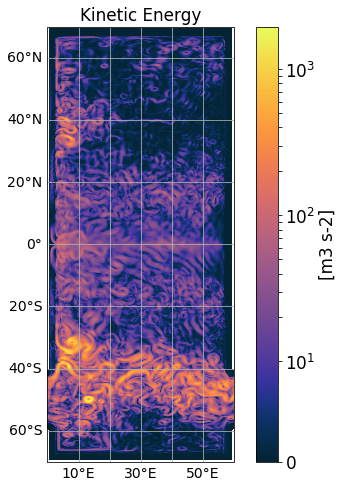

In [9]:
fig,ax = plt.subplots(1,1,figsize=(8,8),subplot_kw={'projection':ccrs.PlateCarree()})


hKE.plot(ax=ax,cbar_kwargs={"label":   '[m3 s-2]'},
              norm=mpl.colors.SymLogNorm(linthresh=10),
            cmap=cmocean.cm.thermal,
            #vmin=vmin,vmax=vmax,   
              transform=ccrs.PlateCarree())

ax.set(title='Kinetic Energy')
ax.set_extent([0, 60, -70, 70], crs=ccrs.PlateCarree())
    #ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_right = False
    #gl.ylocator = mticker.FixedLocator([35, 40, 45, 50])
plt.savefig('figures/hKE_16deg.png', dpi=400,bbox_inches='tight',pad_inches=0)